# **Heart Failure Insights and Visualizations**

In [16]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 398.0 kB/s  0:00:26m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
heart = pd.read_csv('../data/heart.csv')
heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
display(heart.info())

display(heart.describe())

display(heart.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

In [20]:
fig = sp.make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Age Distribution of Heart Disease Patients',
        'Cholesterol Levels Distribution',
        'Resting Blood Pressure Distribution',
        'Age vs Cholesterol Levels'
    )
)

fig_age_hist = px.histogram(heart, x='Age', nbins=30)
fig_chol_hist = px.histogram(heart, x='Cholesterol', nbins=30)
fig_bp_box = px.box(heart, y='RestingBP')
fig_scatter = px.scatter(heart, x='Age', y='Cholesterol', color='HeartDisease')

fig.add_trace(
    fig_age_hist.data[0],
    row=1, col=1
)

fig.add_trace(
    fig_chol_hist.data[0],
    row=1, col=2
)

fig.add_trace(
    fig_bp_box.data[0],
    row=2, col=1
)

for trace in fig_scatter.data:
    fig.add_trace(
        trace,
        row=2, col=2
    )

fig.update_xaxes(title_text="Age", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)

fig.update_xaxes(title_text="Cholesterol", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)

fig.update_yaxes(title_text="Resting Blood Pressure", row=2, col=1)

fig.update_xaxes(title_text="Age", row=2, col=2)
fig.update_yaxes(title_text="Cholesterol", row=2, col=2)

fig.update_layout(
    height=800,
    title_text="Heart Disease Analysis Dashboard",
    template="plotly_dark"
)
fig.show()

fig = px.bar(heart, x='Age', y='HeartDisease', title='Heart Disease Count by Age', template='plotly_dark')
fig.show()

HeartDisease
1    508
0    410
Name: count, dtype: int64


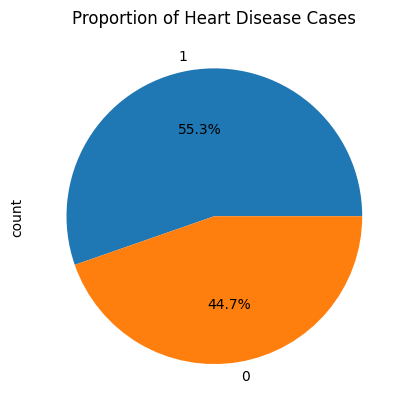

In [ ]:
heart['HeartDisease'].value_counts().plot.pie(autopct='%1.1f%%', title='Proportion of Heart Disease Cases')

### **Predictions**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

heart_ML = heart.copy()


In [23]:
heart_ML.drop(columns=['HeartDisease_Cat'], inplace=True)

In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

In [31]:
X = heart_ML.drop('HeartDisease', axis=1)
y = heart_ML['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),        # Standardize numerical data
    (OneHotEncoder(handle_unknown='ignore'), categorical_features), # One-hot encode categorical data
    remainder='passthrough'
)
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(X_test_processed)

display("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
fig_cm = px.imshow(np.flipud(cm), 
                   text_auto=True,
                   template='plotly_dark',
                   labels=dict(x="Predicted Label", y="True Label"),
                   x=['0 (No HD)', '1 (HD)'],
                   y=['1 (HD)', '0 (No HD)']
                  )

fig_cm.update_layout(
    title='Confusion Matrix',
    coloraxis_showscale=False
)

fig_cm.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

'Confusion Matrix:'


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [37]:
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)) 
])

full_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('standardscaler', ...), ('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
# To use the model for predictions:

def predict_heart_disease(input_data):
    """
    Predict heart disease based on input data.
    
    Parameters:
    input_data (dict): A dictionary containing feature values.
    
    Returns:
    int: Predicted class (0 or 1).
    """
    input_df = pd.DataFrame([input_data])
    prediction = full_pipeline.predict(input_df)
    return prediction[0]

# Example usage:
sample_input = {
    'Age': 55,
    'Sex': 'M',
    'ChestPainType': 'ATA',
    'RestingBP': 140,
    'Cholesterol': 250,
    'FastingBS': 0,
    'RestingECG': 'Normal',
    'MaxHR': 150,
    'ExerciseAngina': 'N',
    'Oldpeak': 1.0,
    'ST_Slope': 'Up'
}

predicted_class = predict_heart_disease(sample_input)
heart_diagnosis = 'Heart Disease' if predicted_class == 1 else 'No Heart Disease'
print(f"Predicted class: {predicted_class}")
print(f"Heart diagnosis: {heart_diagnosis}")

Predicted class: 0
Heart diagnosis: No Heart Disease
